# Week 08 (evaluation): load checkpoints, sample, run the ablation

This notebook is the evaluation half of the Week 08 work. It assumes
`09a_unconditioned_train.ipynb` has been run end-to-end and has produced two checkpoint
files in this directory: `ckpt_full.ckpt` and `ckpt_blind.ckpt`.

The split between training and evaluation is deliberate. Definitions are
stable (they live in `unconditioned_infrastructure.py`); evaluations are exploratory and you
will probably re-run this notebook several times as you iterate on
diagnostics. Putting every diagnostic in its own notebook means you can do
that without ever retraining.

The tasks below pick up where `09a_unconditioned_train.ipynb` left off:
- **Task 39 (loaded)**: re-run the t-sensitivity check on the *loaded* models,
  not the freshly-initialized ones. Defends against silent state-dict
  corruption — if the loaded model somehow drops the timestep embedding, you
  want to know now, before reading the ablation result.
- **Task 42**: quick visualization of a few sampled residuals.
- **Task 43**: distributional verification (bin-wise mean, std, covariance)
  for the full model alone, against the training distribution.
- **Task 44 (evaluation)**: the headline ablation comparison — same
  diagnostics, both models, side by side.


In [1]:
import os, subprocess, sys

# Keep this path if working in Colab
# repo_path = "/content/butterflai"

# Use this path if working locally
repo_path = "../../"

if not os.path.isdir(repo_path):
    subprocess.run(["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path], check=True)
else:
    try:
        subprocess.run(["git", "-C", repo_path, "pull"], check=True)
    except subprocess.CalledProcessError as e:
        print(f"git pull skipped: {e}")
sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()


Already up to date.
  Installing from /home/russell/ButterflAI/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Local
   Device   : cuda
   Seed     : 42


{'in_colab': False,
 'device': device(type='cuda'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

In [2]:
%load_ext autoreload
%autoreload 2

import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
from einops import repeat


In [3]:
# ── locate repo root + week-08/09 artifacts (split across two folders) ─────
# The week-08 deliverables are currently spread between weeks/week_08/ and
# weeks/week_09/. We search both for each artifact independently so the
# notebook works regardless of where any given file sits.
def _find(filename, search_dirs):
    for d in search_dirs:
        p = os.path.join(d, filename)
        if os.path.isfile(p):
            return p
    return None

_cwd = os.getcwd()
_search_dirs = []
for _base in [_cwd] + [os.path.abspath(os.path.join(_cwd, *[".."] * i)) for i in range(0, 5)]:
    for _sub in [("weeks", "week_09"), ("weeks", "week_08")]:
        _candidate = os.path.join(_base, *_sub)
        if os.path.isdir(_candidate) and _candidate not in _search_dirs:
            _search_dirs.append(_candidate)
    # Also handle being launched from inside a week_XX dir
    if ("week_08" in _base or "week_09" in _base) and os.path.isdir(_base) and _base not in _search_dirs:
        _search_dirs.append(_base)

_models_py    = _find("unconditioned_infrastructure.py",            _search_dirs)
_parquet_path = _find("diffusion_windows.parquet", _search_dirs)

_missing = [n for n, p in [
    ("unconditioned_infrastructure.py",            _models_py),
    ("diffusion_windows.parquet", _parquet_path),
] if p is None]
if _missing:
    raise FileNotFoundError(
        f"Cannot locate {_missing} under weeks/week_08 or weeks/week_09. "
        f"Searched: {_search_dirs}"
    )

# Repo root is the parent of whichever weeks/ dir we found
_repo_root = os.path.abspath(os.path.join(os.path.dirname(_models_py), "..", ".."))

# Make every directory that holds an importable module reachable
for _p in [_repo_root, os.path.dirname(_models_py)]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

from unconditioned_infrastructure import (
    make_cosine_schedule, ResidualDataset,
    DiffusionMLP, DiffusionLightning, sample,
)

# ── data needed for the comparisons (same parquet as training) ─────────────
windows_df = pd.read_parquet(_parquet_path)

LAT_BINS    = np.linspace(0, 45, 16)
BIN_WIDTH   = 3.0
BIN_CENTERS = 0.5 * (LAT_BINS[:-1] + LAT_BINS[1:])

# Training dataset is rebuilt just to obtain the in-physical-units residuals
# for the comparison plots. `sample()` itself does not need this object —
# it pulls bin_means / bin_stds from the loaded LightningModule's buffers.
train_dataset = ResidualDataset(windows_df, "train")
val_dataset   = ResidualDataset(windows_df, "val")

bin_means_np   = train_dataset.bin_means.numpy()
bin_stds_np    = train_dataset.bin_stds.numpy()
all_train_phys = (torch.stack([train_dataset[i] for i in range(len(train_dataset))]).numpy()
                  * bin_stds_np + bin_means_np)
all_val_phys   = (torch.stack([val_dataset[i]   for i in range(len(val_dataset))]).numpy()
                  * bin_stds_np + bin_means_np)

# ── schedule arrays (only needed to satisfy DiffusionLightning's constructor
#    signature at load time; the actual values come from the checkpoint buffers)
T = 200
alpha_np, sigma_np, _ = make_cosine_schedule(T=T, s=0.008)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Loaded {len(windows_df)} windows from {_parquet_path}")
print(f"  splits : {windows_df['split'].value_counts().sort_index().to_dict()}")


Device: cuda
Loaded 373 windows from /home/russell/ButterflAI/butterflai/weeks/week_08/diffusion_windows.parquet
  splits : {'test': 86, 'train': 232, 'val': 55}


---
## Load both checkpoints

Lightning's `load_from_checkpoint` reconstructs the module by replaying the
constructor with the saved hyperparameters — but the `model` argument is a
`nn.Module` instance that has to be passed explicitly at load time (you
cannot serialize a Python class instance and recover it from JSON), and the
schedule / bin-statistics buffers are restored from the checkpoint's
state_dict on top of placeholders. The pattern below handles both.


In [4]:
# ── load both checkpoints ──────────────────────────────────────────────────
def _load(model_kwargs, ckpt_name):
    # Build a fresh model with the right architecture flag, then let
    # load_from_checkpoint overwrite its weights and the schedule / bin
    # buffers from the checkpoint state_dict.
    inner = DiffusionMLP(**model_kwargs)
    placeholder_means = np.zeros(15, dtype=np.float32)
    placeholder_stds  = np.ones(15,  dtype=np.float32)
    lm = DiffusionLightning.load_from_checkpoint(
        ckpt_name,
        model=inner,
        alpha=alpha_np, sigma=sigma_np,
        bin_means=placeholder_means, bin_stds=placeholder_stds,
        map_location=device,
    )
    return lm.to(device).eval()

lightning_full  = _load({"use_timestep_embedding": True},  "./ckpt_full.ckpt")
lightning_blind = _load({"use_timestep_embedding": False}, "./ckpt_blind.ckpt")

# Sanity check: the loaded models should have inherited the correct bin
# statistics from training. If these are still the placeholder zeros/ones,
# the checkpoint was saved without bin buffers and `sample()` will not
# de-standardize correctly.
print("Loaded models OK.")
print(f"  full  bin_means[:3]  = {lightning_full.bin_means[:3].cpu().numpy()}  "
      f"(should NOT be all zeros)")
print(f"  blind bin_stds[:3]   = {lightning_blind.bin_stds[:3].cpu().numpy()}  "
      f"(should NOT be all ones)")


Loaded models OK.
  full  bin_means[:3]  = [-0.00320915  0.00010583  0.00039436]  (should NOT be all zeros)
  blind bin_stds[:3]   = [0.0089687  0.01836806 0.02306177]  (should NOT be all ones)


---
## Task 39 (loaded) — t-sensitivity check on the *loaded* models

The training notebook verified t-sensitivity on freshly-initialized models.
This is the same check on the loaded models. If something went wrong during
serialization or loading (e.g. the TimestepEmbedding's state did not transfer
correctly), the full model could behave like the blind one in a way that
silently invalidates every Task 44 conclusion.


In [5]:
# ── Task 39: t-sensitivity on the loaded models ────────────────────────────
torch.manual_seed(1)
r_t_fixed = torch.randn(15, device=device)
t_values  = torch.tensor([0, T // 4, T // 2, 3 * T // 4, T - 1],
                         dtype=torch.long, device=device)
r_t_batch = repeat(r_t_fixed, "d -> n d", n=t_values.shape[0])

with torch.no_grad():
    out_full  = lightning_full.model(r_t_batch,  t_values)
    out_blind = lightning_blind.model(r_t_batch, t_values)

# Blind outputs must be exactly equal across all t (network is t-blind).
for i in range(5):
    for j in range(5):
        assert torch.allclose(out_blind[i], out_blind[j]), \
            "loaded blind model differs across t — checkpoint corruption?"

print(f"full  loaded model: max pairwise L2 across t  = "
      f"{(out_full[None] - out_full[:, None]).norm(dim=-1).max().item():.4f}")
print(f"blind loaded model: max pairwise L2 across t  = "
      f"{(out_blind[None] - out_blind[:, None]).norm(dim=-1).max().item():.4e}  (must be 0)")
print("\nt-sensitivity check on loaded models passed.")


full  loaded model: max pairwise L2 across t  = 4.4726
blind loaded model: max pairwise L2 across t  = 0.0000e+00  (must be 0)

t-sensitivity check on loaded models passed.


---
## Task 42 — Quick sample visualization

The DDIM sampler (in `unconditioned_infrastructure.py` as the `sample` function) runs the
reverse process from r_T ~ N(0, I) down to r_0, deterministically. It pulls
the schedule and the bin standardization stats from the LightningModule's
buffers, so the returned samples are in *physical* residual units — directly
comparable to the training residuals plotted in `09a_unconditioned_train.ipynb` Task 34.

This is a "do they look like residuals" pre-check before the quantitative
comparison in Task 43.


sample() output: shape=(8, 15), finite=True


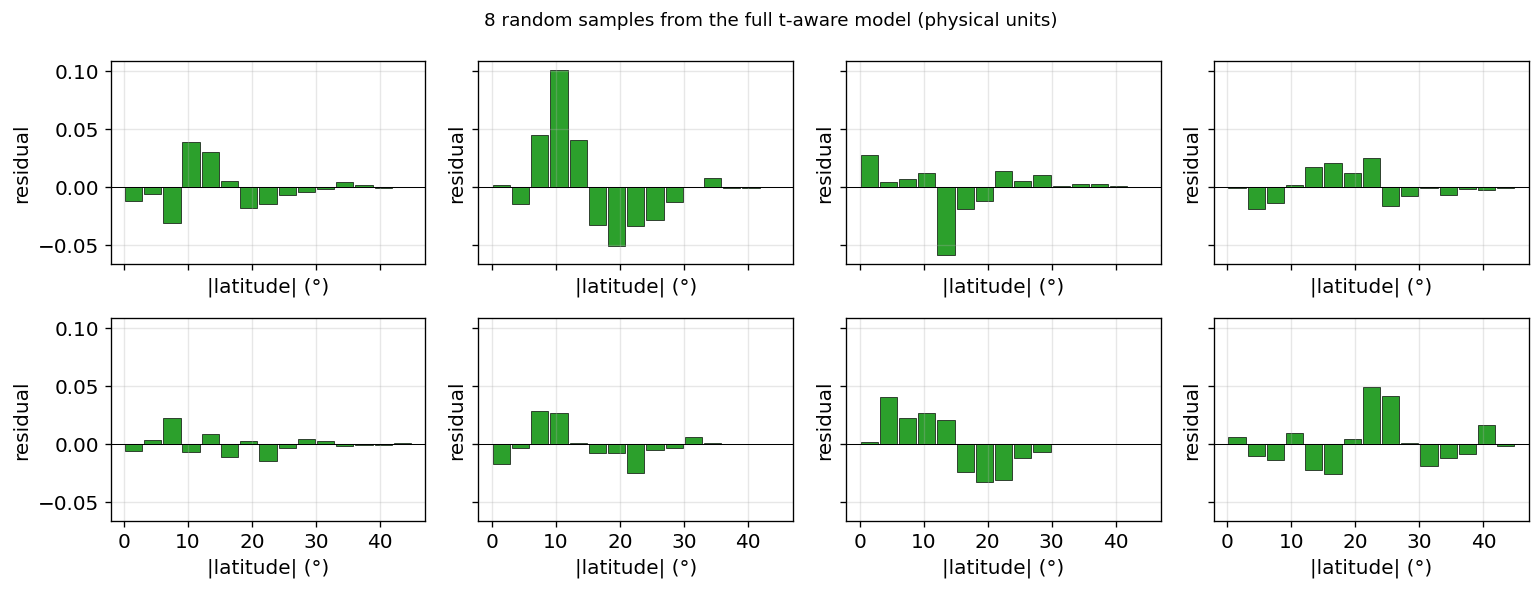

In [6]:
# ── Task 42: 8 quick samples for visual smell test ─────────────────────────
torch.manual_seed(0)
samples_quick = sample(lightning_full, batch_size=8, data_dim=15, device=device)
print(f"sample() output: shape={tuple(samples_quick.shape)}, "
      f"finite={torch.isfinite(samples_quick).all().item()}")

fig, axes = plt.subplots(2, 4, figsize=(13, 5), sharex=True, sharey=True)
for ax, row in zip(axes.flat, samples_quick.cpu().numpy()):
    ax.bar(BIN_CENTERS, row, width=BIN_WIDTH * 0.9,
           color="C2", edgecolor="black", linewidth=0.4)
    ax.axhline(0, color="k", linewidth=0.6)
    ax.set_xlabel("|latitude| (°)"); ax.set_ylabel("residual")
fig.suptitle("8 random samples from the full t-aware model (physical units)", fontsize=11)
plt.tight_layout(); plt.show()


---
## Task 43 — Distributional verification (full model vs. training)

Training loss tells you the network is learning *something*; it does not
tell you it has learned the *right* thing. The direct empirical question is
whether samples from the trained model match the training residual
distribution on bin-wise mean, bin-wise standard deviation, and bin-bin
covariance structure.

If the marginal means and stds agree but the covariance collapses, the model
has learned the marginals without the cross-bin correlations that
distinguish real residuals from white noise — typical signature of an
under-conditioned diffusion model. If the marginals also disagree, training
has not converged or the schedule is mis-tuned.


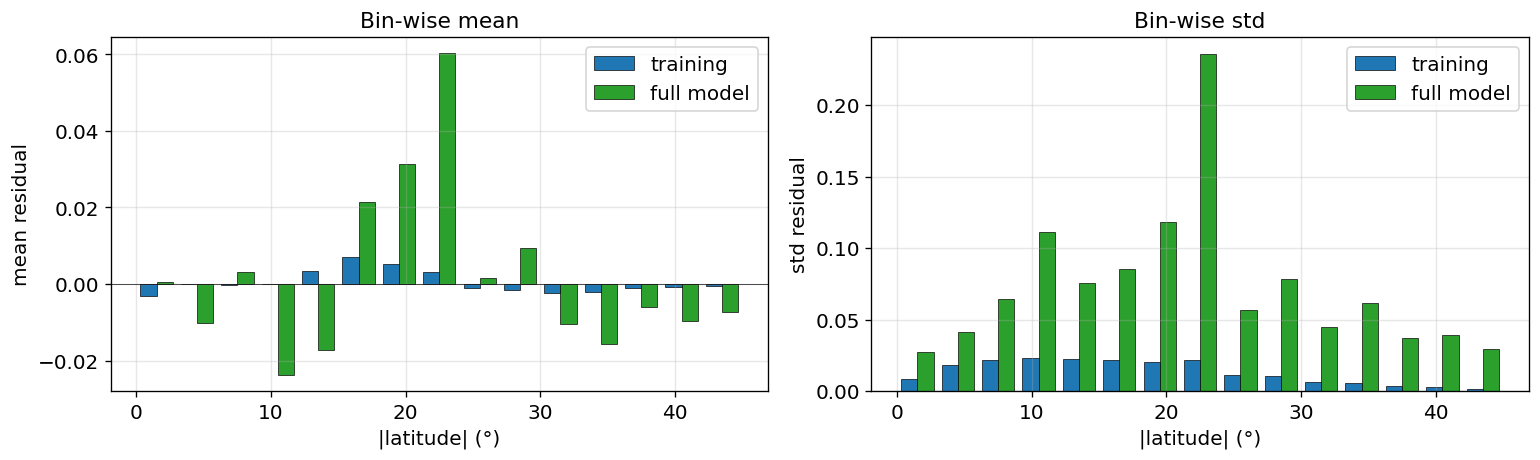

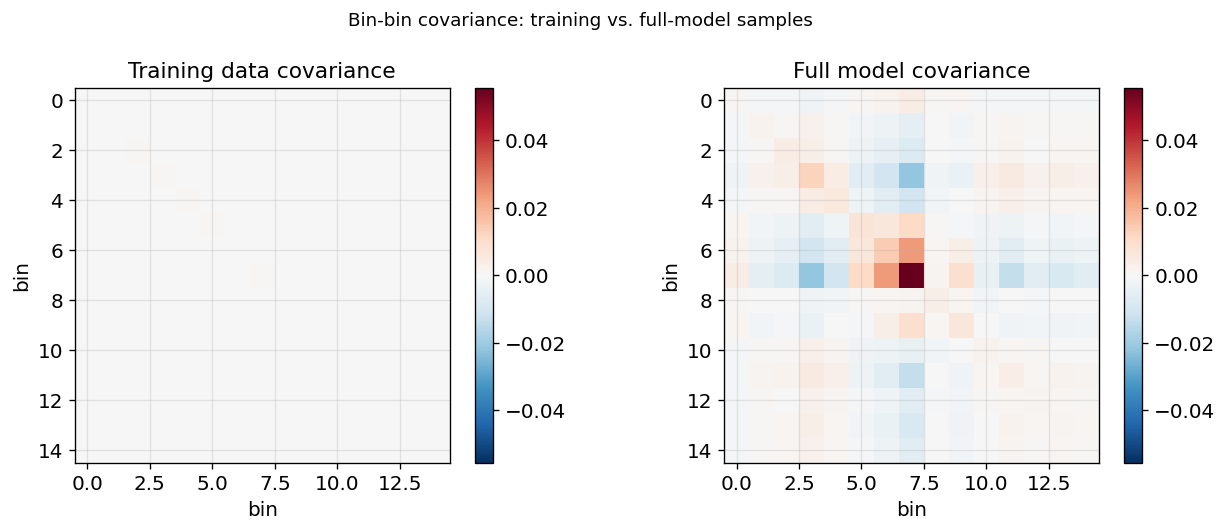

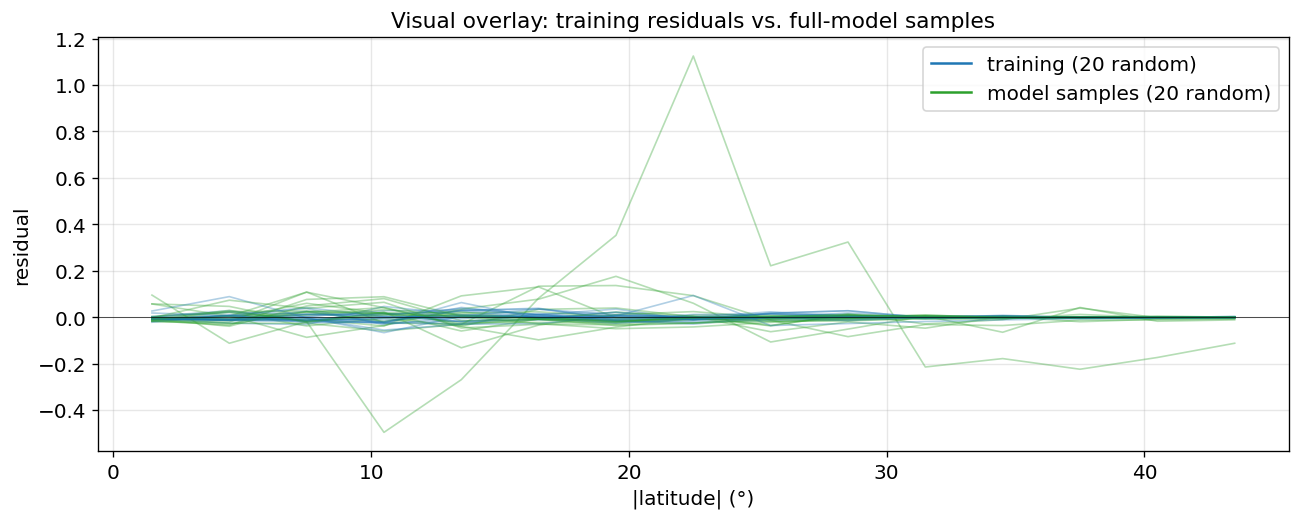


Bin-wise mean MSE (full vs. training): 3.872e-04
Bin-wise std  MSE (full vs. training): 5.823e-03
Frobenius ||cov_full − cov_train||   : 9.028e-02


In [7]:
# ── Task 43: distributional comparison, full model vs. training set ────────
N_COMPARE = 1000

samples_full = sample(lightning_full, batch_size=N_COMPARE, data_dim=15,
                      device=device).cpu().numpy()

rng = np.random.default_rng(123)
train_arr = all_train_phys[rng.integers(0, len(all_train_phys), size=N_COMPARE)]

mean_train, mean_full = train_arr.mean(axis=0), samples_full.mean(axis=0)
std_train,  std_full  = train_arr.std(axis=0),  samples_full.std(axis=0)
cov_train, cov_full   = np.cov(train_arr, rowvar=False), np.cov(samples_full, rowvar=False)

# Bin-wise mean and std panels
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)
w = BIN_WIDTH * 0.4
axes[0].bar(BIN_CENTERS - w / 2, mean_train, width=w, color="C0", label="training",
            edgecolor="black", linewidth=0.4)
axes[0].bar(BIN_CENTERS + w / 2, mean_full,  width=w, color="C2", label="full model",
            edgecolor="black", linewidth=0.4)
axes[0].axhline(0, color="k", linewidth=0.4)
axes[0].set_title("Bin-wise mean"); axes[0].set_xlabel("|latitude| (°)")
axes[0].set_ylabel("mean residual"); axes[0].legend()

axes[1].bar(BIN_CENTERS - w / 2, std_train, width=w, color="C0", label="training",
            edgecolor="black", linewidth=0.4)
axes[1].bar(BIN_CENTERS + w / 2, std_full,  width=w, color="C2", label="full model",
            edgecolor="black", linewidth=0.4)
axes[1].set_title("Bin-wise std"); axes[1].set_xlabel("|latitude| (°)")
axes[1].set_ylabel("std residual"); axes[1].legend()
plt.tight_layout(); plt.show()

# Covariance heatmaps
vmax_cov = max(np.abs(cov_train).max(), np.abs(cov_full).max())
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, mat, title in [(axes[0], cov_train, "Training data covariance"),
                       (axes[1], cov_full,  "Full model covariance")]:
    im = ax.imshow(mat, cmap="RdBu_r", vmin=-vmax_cov, vmax=vmax_cov)
    ax.set_title(title); ax.set_xlabel("bin"); ax.set_ylabel("bin")
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("Bin-bin covariance: training vs. full-model samples", fontsize=11)
plt.tight_layout(); plt.show()

# Visual overlay
rng2 = np.random.default_rng(7)
fig, ax = plt.subplots(figsize=(11, 4.5))
for i in rng2.choice(N_COMPARE, size=20, replace=False):
    ax.plot(BIN_CENTERS, train_arr[i],    color="C0", alpha=0.35, lw=1.0)
    ax.plot(BIN_CENTERS, samples_full[i], color="C2", alpha=0.35, lw=1.0)
ax.plot([], [], color="C0", label="training (20 random)")
ax.plot([], [], color="C2", label="model samples (20 random)")
ax.axhline(0, color="k", linewidth=0.4)
ax.set_xlabel("|latitude| (°)"); ax.set_ylabel("residual")
ax.set_title("Visual overlay: training residuals vs. full-model samples")
ax.legend(); plt.tight_layout(); plt.show()

binwise_mean_mse_full = float(np.mean((mean_full - mean_train) ** 2))
binwise_std_mse_full  = float(np.mean((std_full  - std_train) ** 2))
cov_frob_full         = float(np.linalg.norm(cov_full - cov_train))
print(f"\nBin-wise mean MSE (full vs. training): {binwise_mean_mse_full:.3e}")
print(f"Bin-wise std  MSE (full vs. training): {binwise_std_mse_full:.3e}")
print(f"Frobenius ||cov_full − cov_train||   : {cov_frob_full:.3e}")


---
## Task 44 (evaluation) — Ablation comparison

The same diagnostics from Task 43, run for both models side by side. The
qualitative headline is the three-way covariance heatmap: does the blind
model's covariance match the training data's, or has it collapsed to
something more diagonal?

**How to read the result:**

- *If the full model clearly beats the blind model* on covariance match:
  the timestep embedding earns its keep. The architectural complexity is
  doing real work, and Week 09's conditioning machinery should be built on
  top of the t-aware base.
- *If the two models are nearly tied:* the timestep embedding is not
  contributing much on this dataset. Possible reasons: 200 timesteps is
  more than this 15-dimensional residual problem needs (a network can
  approximately memorize an "average denoiser" when the noise levels are
  not too varied); the cosine schedule keeps the signal alive across a
  large fraction of t (so the average denoiser is not far from any specific
  denoiser); or the data does not have enough structure across noise levels
  for t-awareness to matter. None of these is a bug — they are real findings
  about this problem at this scale.
- *If the blind model outperforms the full model:* a real bug somewhere,
  most likely in the TimestepEmbedding wiring. Re-run the t-sensitivity
  check on the loaded full model — if pairwise distances are exactly zero,
  the checkpoint is broken.

Either of the first two outcomes is publishable insight about your specific
problem. The result is not predetermined — that is what makes this an
ablation rather than a demonstration.


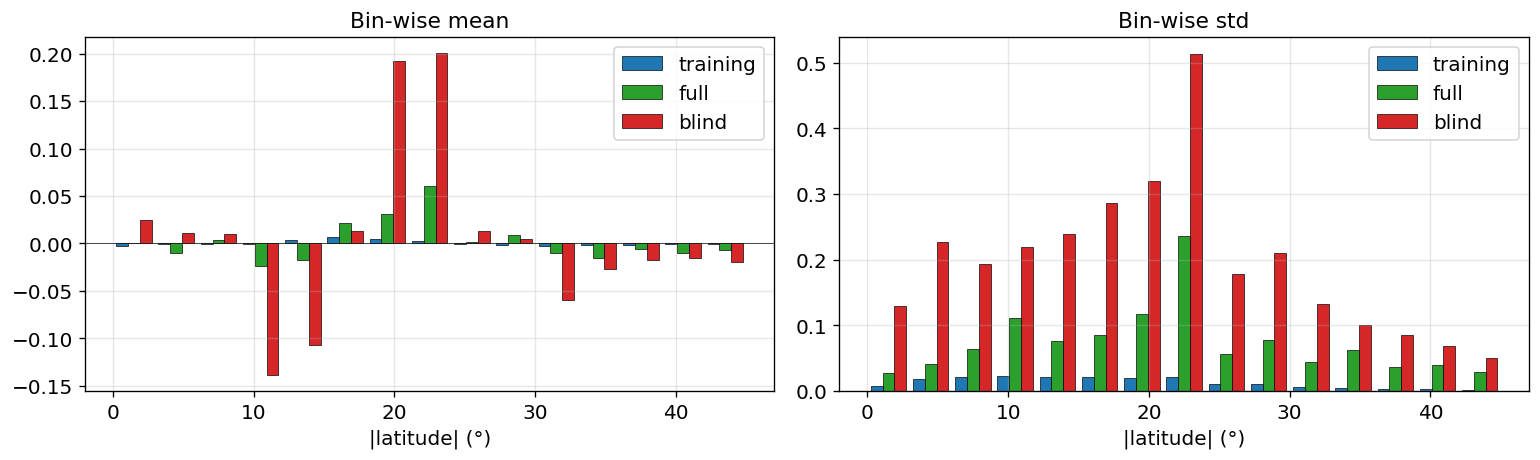

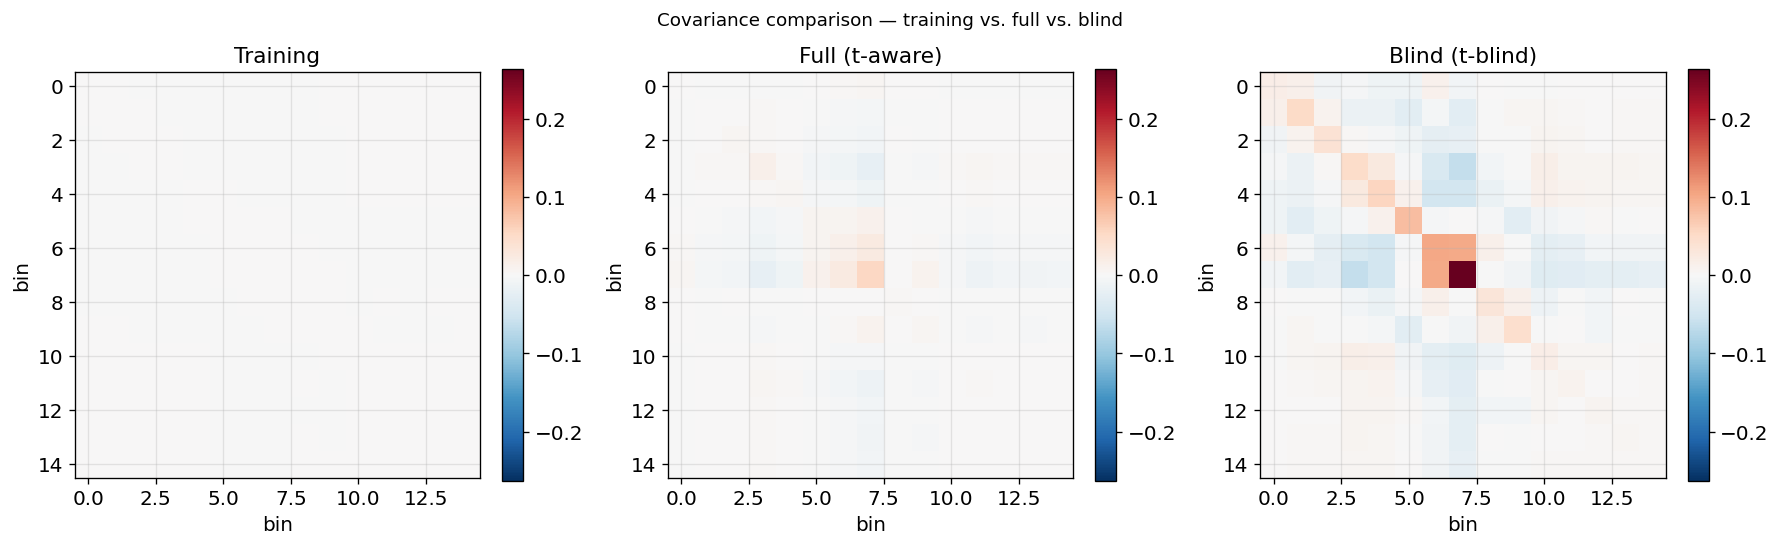


Ablation comparison (all metrics in physical residual units)
            row  binwise_mean_MSE  binwise_std_MSE  cov_frobenius_dist
       training          0.000000         0.000000            0.000000
full  (t-aware)          0.000387         0.005823            0.090278
blind (t-blind)          0.007434         0.045369            0.407903

Covariance verdict: full noticeably better (timestep embedding earns its keep)
  full  ||cov − cov_train||_F = 9.028e-02
  blind ||cov − cov_train||_F = 4.079e-01


In [8]:
# ── Task 44 (eval): full vs. blind, same diagnostics ───────────────────────
torch.manual_seed(0)
samples_blind = sample(lightning_blind, batch_size=N_COMPARE, data_dim=15,
                       device=device).cpu().numpy()

mean_blind = samples_blind.mean(axis=0)
std_blind  = samples_blind.std(axis=0)
cov_blind  = np.cov(samples_blind, rowvar=False)

# Three-way bin-wise mean and std
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)
w = BIN_WIDTH * 0.28
for ax, train_vals, full_vals, blind_vals, title in [
    (axes[0], mean_train, mean_full, mean_blind, "Bin-wise mean"),
    (axes[1], std_train,  std_full,  std_blind,  "Bin-wise std"),
]:
    ax.bar(BIN_CENTERS - w, train_vals, width=w, label="training",
           color="C0", edgecolor="black", linewidth=0.4)
    ax.bar(BIN_CENTERS,     full_vals,  width=w, label="full",
           color="C2", edgecolor="black", linewidth=0.4)
    ax.bar(BIN_CENTERS + w, blind_vals, width=w, label="blind",
           color="C3", edgecolor="black", linewidth=0.4)
    ax.axhline(0, color="k", linewidth=0.4)
    ax.set_title(title); ax.set_xlabel("|latitude| (°)"); ax.legend()
plt.tight_layout(); plt.show()

# Three-way covariance heatmaps — this is the headline comparison
vmax_cov = max(np.abs(cov_train).max(), np.abs(cov_full).max(), np.abs(cov_blind).max())
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, mat, title in [(axes[0], cov_train, "Training"),
                       (axes[1], cov_full,  "Full (t-aware)"),
                       (axes[2], cov_blind, "Blind (t-blind)")]:
    im = ax.imshow(mat, cmap="RdBu_r", vmin=-vmax_cov, vmax=vmax_cov)
    ax.set_title(title); ax.set_xlabel("bin"); ax.set_ylabel("bin")
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("Covariance comparison — training vs. full vs. blind", fontsize=11)
plt.tight_layout(); plt.show()

# Comparison table
binwise_mean_mse_blind = float(np.mean((mean_blind - mean_train) ** 2))
binwise_std_mse_blind  = float(np.mean((std_blind  - std_train) ** 2))
cov_frob_blind         = float(np.linalg.norm(cov_blind - cov_train))

comparison = pd.DataFrame([
    {"row": "training",          "binwise_mean_MSE": 0.0,
     "binwise_std_MSE": 0.0,            "cov_frobenius_dist": 0.0},
    {"row": "full  (t-aware)",   "binwise_mean_MSE": binwise_mean_mse_full,
     "binwise_std_MSE": binwise_std_mse_full,  "cov_frobenius_dist": cov_frob_full},
    {"row": "blind (t-blind)",   "binwise_mean_MSE": binwise_mean_mse_blind,
     "binwise_std_MSE": binwise_std_mse_blind, "cov_frobenius_dist": cov_frob_blind},
])

cov_verdict = ("full noticeably better (timestep embedding earns its keep)"
               if cov_frob_full < cov_frob_blind * 0.9
               else "approximately tied (the dataset does not require t-awareness)")

print("\nAblation comparison (all metrics in physical residual units)")
print("=" * 70)
print(comparison.to_string(index=False))
print(f"\nCovariance verdict: {cov_verdict}")
print(f"  full  ||cov − cov_train||_F = {cov_frob_full:.3e}")
print(f"  blind ||cov − cov_train||_F = {cov_frob_blind:.3e}")


---
## Where Week 08 leaves us, and what Week 09 will need

By the end of this notebook you have:

- A trained **unconditional** diffusion model that learns the marginal
  residual distribution and samples from it (the `ckpt_full*.ckpt` pair).
- A trained **t-blind ablation** showing whether the timestep embedding
  earns its keep on this dataset (the `ckpt_blind*.ckpt` pair).
- A distributional verification — bin-wise mean, std, covariance — confirming
  that the full model's samples match the training residuals (or surfacing
  in honest detail where they do not).
- An ablation comparison table you can carry into Week 09 as the baseline
  against which the conditional model will be measured.

What you have **not** yet built is conditioning: every sample drawn from the
trained model is from the *marginal* residual distribution, not from a
distribution targeted at a specific window. That is the Week 09 lift.

**What changes in Week 09.** The Dataset returns `(r, amplitude, mu_universal)`
tuples instead of just `r`. The DiffusionMLP gains a second concatenation
input — the conditioning vector — alongside r_t (no separate ConditionEmbedding
module this week; we go minimal-machinery first and revisit in the
experimentation week). The LightningModule's `training_step` passes the
conditioning through. The sampler accepts a per-sample conditioning vector
and threads it through each reverse step.

**What stays.** Every line of `training_step` that handles the schedule.
Every callback. The two-notebook split. The script structure. Week 09 is a
small refactor on a working pipeline, not a rebuild.
